In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"
df = pd.read_csv(path)

df.shape

(30000, 31)

In [ ]:
y = df['default']

early_warning_features = [
    'pay_delay_trend',
    'pay_delay_volatility',
    'recency_weighted_stress',
    'bill_payment_ratio',
    'LIMIT_BAL',
    'AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'
]

X = df[early_warning_features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
df_test = X_test.copy()
df_test['true_default'] = y_test.values
df_test['default_probability'] = model.predict_proba(X_test)[:, 1]

df_test[['default_probability']].describe()

,default_probability
count,9000.000000
mean,0.222426
std,0.161827
min,0.017008
25%,0.119243
50%,0.168122
75%,0.286964
max,0.989464


In [ ]:
low_risk_threshold = 0.2
high_risk_threshold = 0.5

def assign_risk(prob):
    if prob < low_risk_threshold:
        return 'Low Risk'
    elif prob < high_risk_threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

df_test['risk_segment'] = df_test['default_probability'].apply(assign_risk)

df_test['risk_segment'].value_counts(normalize=True)

,proportion
risk_segment,
Low Risk,0.632556
Medium Risk,0.292778
High Risk,0.074667


In [ ]:
df_test.groupby('risk_segment')['true_default'].mean()

,true_default
risk_segment,
High Risk,0.638393
Low Risk,0.122080
Medium Risk,0.329032


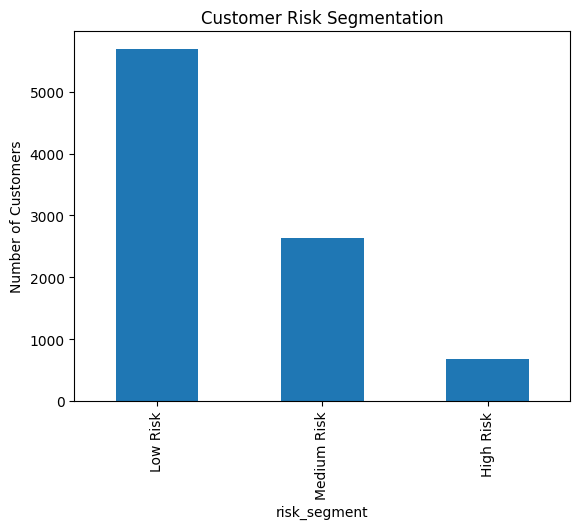

In [ ]:
plt.figure()
df_test['risk_segment'].value_counts().plot(kind='bar')
plt.title("Customer Risk Segmentation")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
action_map = {
    'Low Risk': 'Offer credit line increase / rewards',
    'Medium Risk': 'Monitor & soft reminders',
    'High Risk': 'Early intervention / payment plans'
}

df_test['recommended_action'] = df_test['risk_segment'].map(action_map)

df_test[['default_probability', 'risk_segment', 'recommended_action']].head()

,default_probability,risk_segment,recommended_action
8941,0.134185,Low Risk,Offer credit line increase / rewards
17618,0.408098,Medium Risk,Monitor & soft reminders
27895,0.159412,Low Risk,Offer credit line increase / rewards
16103,0.554592,High Risk,Early intervention / payment plans
4422,0.159807,Low Risk,Offer credit line increase / rewards


In [ ]:
cost_false_negative = 10   # missed defaulter
cost_false_positive = 1    # unnecessary intervention

df_test['pred_default'] = (df_test['default_probability'] >= high_risk_threshold).astype(int)

false_negatives = ((df_test['pred_default'] == 0) & (df_test['true_default'] == 1)).sum()
false_positives = ((df_test['pred_default'] == 1) & (df_test['true_default'] == 0)).sum()

total_cost = (
    false_negatives * cost_false_negative +
    false_positives * cost_false_positive
)

false_negatives, false_positives, total_cost

(np.int64(1562), np.int64(243), np.int64(15863))

In [ ]:
save_path = "/content/drive/MyDrive/Credit_Risk_Project/data/scored_customers.csv"
df_test.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Credit_Risk_Project/data/scored_customers.csv
